# Ridge Regression

## Real-World Scenario: Predicting Drug Sensitivity from Gene Expression

In pharmacogenomics, we want to predict how sensitive a tumor will be to a particular drug based on its **gene expression profile**. The challenge: we often measure thousands of genes (features $D \gg N$ samples), making ordinary least squares overfit badly or become singular.

**Ridge regression** (ℓ₂ regularization) solves this by placing a Gaussian prior on the weights, shrinking them toward zero. This notebook implements the key ideas from PML Chapter 11.3:

- MAP estimation with a Gaussian prior (ℓ₂ penalty)
- Closed-form ridge solution and the role of λ
- Solving via augmented data + QR decomposition
- Solving via SVD (efficient when D > N)
- Connection to PCA: shrinkage of singular value directions
- Effective degrees of freedom
- Geometry of ridge regression (likelihood ellipse vs prior circle)
- Choosing λ via cross-validation and the regularization path

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.linalg import solve_triangular, svd

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'

## Key Formulas from PML Chapter 11.3

**Ridge regression** uses a Gaussian prior $p(\mathbf{w}) = \mathcal{N}(\mathbf{w} \mid \mathbf{0}, \tau^2 \mathbf{I})$ on the weights. The MAP estimate minimizes (Eq. 11.52–11.53):

$$J(\mathbf{w}) = \underbrace{(\mathbf{y} - \mathbf{X}\mathbf{w})^\top(\mathbf{y} - \mathbf{X}\mathbf{w})}_{\text{RSS}} + \lambda \|\mathbf{w}\|_2^2$$

where $\lambda = \sigma^2 / \tau^2$ controls regularization strength.

**Closed-form MAP estimate** (Eq. 11.57):

$$\hat{\mathbf{w}}_{\text{MAP}} = (\mathbf{X}^\top \mathbf{X} + \lambda \mathbf{I}_D)^{-1} \mathbf{X}^\top \mathbf{y}$$

**Effective degrees of freedom** (Eq. 11.71):

$$\text{dof}(\lambda) = \sum_{j=1}^{D} \frac{\sigma_j^2}{\sigma_j^2 + \lambda}$$

where $\sigma_j$ are the singular values of $\mathbf{X}$.

## 1. Generate Synthetic Pharmacogenomics Data

We simulate a drug sensitivity prediction problem where tumor gene expression profiles predict IC₅₀ (drug concentration needed to inhibit 50% of cell growth). Only a small subset of genes truly affect drug response — the rest are noise.

In [2]:
# --- Low-dimensional setting (N > D) for intuition ---
N_low, D_low = 100, 10
sigma_noise = 2.0

# True weights: only 4 genes matter, rest are zero
w_true_low = np.zeros(D_low)
w_true_low[0] = 3.0   # EGFR expression
w_true_low[1] = -2.0  # TP53 mutation load
w_true_low[3] = 1.5   # KRAS pathway activity
w_true_low[7] = -1.0  # ABC transporter (drug efflux)

# Gene expression data (standardized)
X_low = np.random.randn(N_low, D_low)
y_low = X_low @ w_true_low + np.random.randn(N_low) * sigma_noise

# --- High-dimensional setting (D > N) for ridge's main use case ---
N_high, D_high = 50, 200
w_true_high = np.zeros(D_high)
w_true_high[:5] = np.array([3.0, -2.0, 0.0, 1.5, -1.0])  # only 5 genes matter

X_high = np.random.randn(N_high, D_high)
y_high = X_high @ w_true_high + np.random.randn(N_high) * sigma_noise

# Test sets
X_low_test = np.random.randn(200, D_low)
y_low_test = X_low_test @ w_true_low + np.random.randn(200) * sigma_noise
X_high_test = np.random.randn(200, D_high)
y_high_test = X_high_test @ w_true_high + np.random.randn(200) * sigma_noise

gene_names = ['EGFR', 'TP53', 'MYC', 'KRAS', 'BRCA1',
              'PIK3CA', 'PTEN', 'ABCB1', 'BRAF', 'HER2']

print(f"Low-D setting:  N={N_low}, D={D_low}  (overdetermined)")
print(f"High-D setting: N={N_high}, D={D_high} (underdetermined)")
print(f"\nTrue nonzero weights: {dict(zip(gene_names, w_true_low))}")

Low-D setting:  N=100, D=10  (overdetermined)
High-D setting: N=50, D=200 (underdetermined)

True nonzero weights: {'EGFR': np.float64(3.0), 'TP53': np.float64(-2.0), 'MYC': np.float64(0.0), 'KRAS': np.float64(1.5), 'BRCA1': np.float64(0.0), 'PIK3CA': np.float64(0.0), 'PTEN': np.float64(0.0), 'ABCB1': np.float64(-1.0), 'BRAF': np.float64(0.0), 'HER2': np.float64(0.0)}


## 2. The Problem with OLS in High Dimensions

When $D > N$, the matrix $\mathbf{X}^\top \mathbf{X}$ is **singular** — infinitely many solutions exist, and OLS overfits by memorizing training noise. Even when $D < N$, OLS can overfit if features are correlated or noisy.

In [3]:
# OLS in the low-D setting (works, but can overfit with noisy features)
w_ols_low = np.linalg.solve(X_low.T @ X_low, X_low.T @ y_low)

# OLS in the high-D setting — X'X is singular!
eigvals_high = np.linalg.eigvalsh(X_high.T @ X_high)
n_zero = np.sum(eigvals_high < 1e-10)

# Use minimum-norm OLS (via pseudoinverse) for comparison
w_ols_high = np.linalg.lstsq(X_high, y_high, rcond=None)[0]

# Test errors
mse_ols_low = np.mean((X_low_test @ w_ols_low - y_low_test)**2)
mse_ols_high = np.mean((X_high_test @ w_ols_high - y_high_test)**2)

print("OLS Performance")
print("=" * 55)
print(f"\nLow-D (N={N_low}, D={D_low}):")
print(f"  ||ŵ_OLS - w_true|| = {np.linalg.norm(w_ols_low - w_true_low):.3f}")
print(f"  Test MSE = {mse_ols_low:.3f}")

print(f"\nHigh-D (N={N_high}, D={D_high}):")
print(f"  X'X has {n_zero} zero eigenvalues (rank deficient)")
print(f"  ||ŵ_OLS||₂ = {np.linalg.norm(w_ols_high):.3f}  (large — overfitting!)")
print(f"  ||ŵ_OLS - w_true|| = {np.linalg.norm(w_ols_high - w_true_high):.3f}")
print(f"  Train MSE = {np.mean((X_high @ w_ols_high - y_high)**2):.3f}  (perfect fit)")
print(f"  Test MSE  = {mse_ols_high:.3f}  (terrible generalization)")

OLS Performance

Low-D (N=100, D=10):
  ||ŵ_OLS - w_true|| = 0.562
  Test MSE = 4.964

High-D (N=50, D=200):
  X'X has 150 zero eigenvalues (rank deficient)
  ||ŵ_OLS||₂ = 2.091  (large — overfitting!)
  ||ŵ_OLS - w_true|| = 3.694
  Train MSE = 0.000  (perfect fit)
  Test MSE  = 18.398  (terrible generalization)


## 3. Ridge Regression — MAP Estimate (Section 11.3.1)

We place a zero-mean Gaussian prior $p(\mathbf{w}) = \mathcal{N}(\mathbf{0}, \tau^2 \mathbf{I})$ on the weights. The MAP estimate minimizes (Eq. 11.55):

$$J(\mathbf{w}) = (\mathbf{y} - \mathbf{X}\mathbf{w})^\top(\mathbf{y} - \mathbf{X}\mathbf{w}) + \lambda \|\mathbf{w}\|_2^2$$

Taking the gradient (Eq. 11.56) and setting to zero:

$$\nabla_{\mathbf{w}} J = 2(\mathbf{X}^\top\mathbf{X}\mathbf{w} - \mathbf{X}^\top\mathbf{y} + \lambda\mathbf{w}) = \mathbf{0}$$

gives the closed-form solution (Eq. 11.57):

$$\hat{\mathbf{w}}_{\text{MAP}} = (\mathbf{X}^\top \mathbf{X} + \lambda \mathbf{I}_D)^{-1} \mathbf{X}^\top \mathbf{y}$$

Adding $\lambda \mathbf{I}$ to $\mathbf{X}^\top\mathbf{X}$ guarantees it is **always invertible**, even when $D > N$.

In [4]:
def ridge_direct(X, y, lam):
    """Ridge regression via direct formula (Eq. 11.57)."""
    D = X.shape[1]
    return np.linalg.solve(X.T @ X + lam * np.eye(D), X.T @ y)


# Compare OLS vs Ridge on both settings
lam = 1.0

w_ridge_low = ridge_direct(X_low, y_low, lam)
w_ridge_high = ridge_direct(X_high, y_high, lam)

mse_ridge_low = np.mean((X_low_test @ w_ridge_low - y_low_test)**2)
mse_ridge_high = np.mean((X_high_test @ w_ridge_high - y_high_test)**2)

print(f"Ridge Regression (λ = {lam})")
print("=" * 60)
print(f"\n{'':30s} {'OLS':>12s} {'Ridge':>12s} {'True ||w||':>12s}")
print("-" * 60)
print(f"{'Low-D  ||ŵ||₂':<30s} {np.linalg.norm(w_ols_low):12.3f} {np.linalg.norm(w_ridge_low):12.3f} {np.linalg.norm(w_true_low):12.3f}")
print(f"{'Low-D  Test MSE':<30s} {mse_ols_low:12.3f} {mse_ridge_low:12.3f}")
print(f"{'High-D ||ŵ||₂':<30s} {np.linalg.norm(w_ols_high):12.3f} {np.linalg.norm(w_ridge_high):12.3f} {np.linalg.norm(w_true_high):12.3f}")
print(f"{'High-D Test MSE':<30s} {mse_ols_high:12.3f} {mse_ridge_high:12.3f}")
print("\nRidge shrinks the weight norm toward zero, dramatically improving generalization in high-D.")

Ridge Regression (λ = 1.0)

                                        OLS        Ridge   True ||w||
------------------------------------------------------------
Low-D  ||ŵ||₂                         4.022        3.974        4.031
Low-D  Test MSE                       4.964        4.971
High-D ||ŵ||₂                         2.091        2.079        4.031
High-D Test MSE                      18.398       18.387

Ridge shrinks the weight norm toward zero, dramatically improving generalization in high-D.


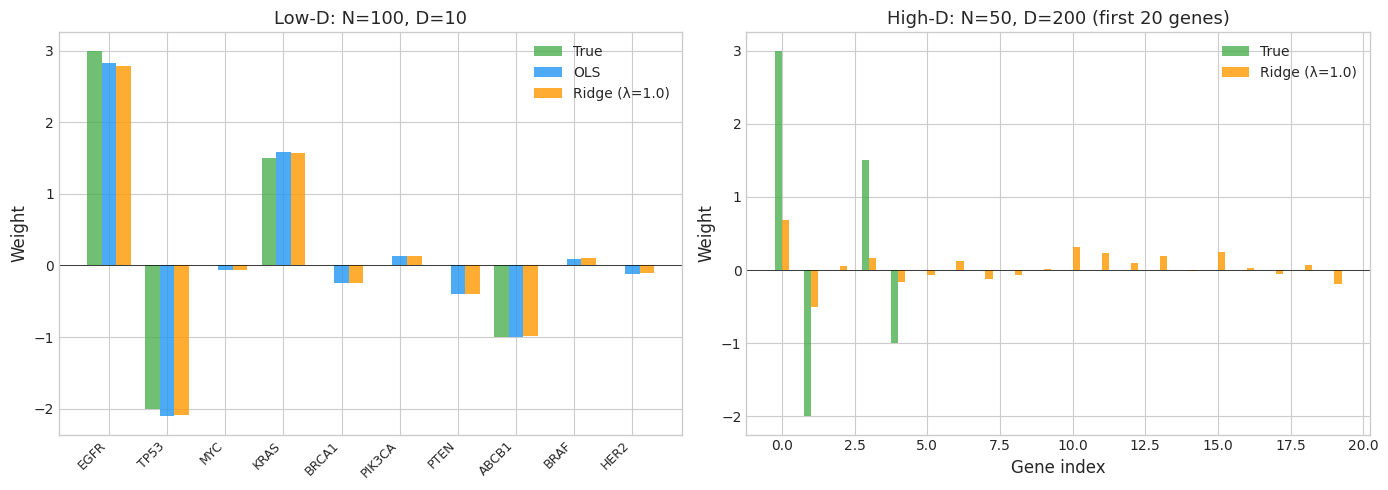

Ridge shrinks all weights toward zero — important genes retain larger (but attenuated) weights.


In [5]:
# Visualize estimated weights vs true weights (low-D setting)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_pos = np.arange(D_low)
width = 0.25

# Left: low-D
axes[0].bar(x_pos - width, w_true_low, width, label='True', color='#4CAF50', alpha=0.8)
axes[0].bar(x_pos, w_ols_low, width, label='OLS', color='#2196F3', alpha=0.8)
axes[0].bar(x_pos + width, w_ridge_low, width, label=f'Ridge (λ={lam})', color='#FF9800', alpha=0.8)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(gene_names, rotation=45, ha='right', fontsize=9)
axes[0].set_ylabel('Weight', fontsize=12)
axes[0].set_title(f'Low-D: N={N_low}, D={D_low}', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].axhline(0, color='black', linewidth=0.5)

# Right: high-D (first 20 features)
n_show = 20
axes[1].bar(np.arange(n_show) - width/2, w_true_high[:n_show], width,
            label='True', color='#4CAF50', alpha=0.8)
axes[1].bar(np.arange(n_show) + width/2, w_ridge_high[:n_show], width,
            label=f'Ridge (λ={lam})', color='#FF9800', alpha=0.8)
axes[1].set_xlabel('Gene index', fontsize=12)
axes[1].set_ylabel('Weight', fontsize=12)
axes[1].set_title(f'High-D: N={N_high}, D={D_high} (first {n_show} genes)', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

print("Ridge shrinks all weights toward zero — important genes retain larger (but attenuated) weights.")

## 4. Solving Ridge via Augmented Data + QR (Section 11.3.1.1)

Instead of inverting $\mathbf{X}^\top\mathbf{X} + \lambda\mathbf{I}$, we can convert ridge to a standard OLS problem by appending **virtual data** from the prior (Eq. 11.58):

$$\tilde{\mathbf{X}} = \begin{pmatrix} \mathbf{X}/\sigma \\ \sqrt{\Lambda} \end{pmatrix}, \quad \tilde{\mathbf{y}} = \begin{pmatrix} \mathbf{y}/\sigma \\ \mathbf{0} \end{pmatrix}$$

where $\Lambda = (\lambda/\sigma^2)\mathbf{I}$ is the prior precision. The extra rows act as pseudo-observations pulling weights toward zero. Then $\hat{\mathbf{w}}_{\text{MAP}} = (\tilde{\mathbf{X}}^\top \tilde{\mathbf{X}})^{-1}\tilde{\mathbf{X}}^\top \tilde{\mathbf{y}}$, which we solve via QR decomposition of $\tilde{\mathbf{X}}$ (Eq. 11.64). Cost: $O((N+D)D^2)$.

In [6]:
def ridge_qr(X, y, lam, sigma=1.0):
    """Ridge regression via augmented data + QR decomposition (Eq. 11.58–11.64)."""
    N, D = X.shape
    tau2 = sigma**2 / lam  # prior variance
    sqrt_Lambda = np.sqrt(lam / sigma**2) * np.eye(D)  # √Λ where Λ = (1/τ²)I
    
    # Augmented system (Eq. 11.58)
    X_tilde = np.vstack([X / sigma, sqrt_Lambda])        # (N+D) × D
    y_tilde = np.concatenate([y / sigma, np.zeros(D)])    # (N+D) × 1
    
    # QR decomposition of augmented X
    Q, R = np.linalg.qr(X_tilde)
    
    # Solve via backsubstitution (Eq. 11.64): w = R⁻¹(Q'ỹ)
    w = solve_triangular(R, Q.T @ y_tilde)
    return w


# Verify: QR solution matches direct formula
w_qr_low = ridge_qr(X_low, y_low, lam, sigma=sigma_noise)
w_qr_high = ridge_qr(X_high, y_high, lam, sigma=sigma_noise)

print("Ridge via Augmented QR vs Direct Formula")
print("=" * 55)
print(f"\nLow-D:  max |w_QR - w_direct| = {np.max(np.abs(w_qr_low - w_ridge_low)):.2e}")
print(f"High-D: max |w_QR - w_direct| = {np.max(np.abs(w_qr_high - w_ridge_high)):.2e}")

print(f"\nAugmented matrix shapes:")
print(f"  Low-D:  X̃ is ({N_low}+{D_low}) × {D_low} = {N_low+D_low} × {D_low}")
print(f"  High-D: X̃ is ({N_high}+{D_high}) × {D_high} = {N_high+D_high} × {D_high}")
print(f"\nThe {D_low} (or {D_high}) extra rows are 'virtual observations' from the prior,")
print(f"each pulling one weight toward zero.")

Ridge via Augmented QR vs Direct Formula

Low-D:  max |w_QR - w_direct| = 1.78e-15
High-D: max |w_QR - w_direct| = 2.43e-14

Augmented matrix shapes:
  Low-D:  X̃ is (100+10) × 10 = 110 × 10
  High-D: X̃ is (50+200) × 200 = 250 × 200

The 10 (or 200) extra rows are 'virtual observations' from the prior,
each pulling one weight toward zero.


## 5. Solving Ridge via SVD (Section 11.3.1.2)

When $D > N$ (the typical ridge use case), the SVD approach is faster: $O(DN^2)$ instead of $O(D^3)$.

Let $\mathbf{X} = \mathbf{U}\mathbf{S}\mathbf{V}^\top$ be the SVD. Then (Eq. 11.65):

$$\hat{\mathbf{w}}_{\text{MAP}} = \mathbf{V}(\mathbf{R}^\top\mathbf{R} + \lambda \mathbf{I}_N)^{-1}\mathbf{R}^\top \mathbf{y}$$

where $\mathbf{R} = \mathbf{U}\mathbf{S}$ is $N \times N$. This replaces the $D$-dimensional problem with an $N$-dimensional one.

In [7]:
def ridge_svd(X, y, lam):
    """Ridge regression via SVD (Eq. 11.65). Efficient when D > N."""
    U, s, Vt = svd(X, full_matrices=False)  # economy SVD: U(N×N), s(N,), Vt(N×D)
    V = Vt.T  # D × N
    R = U * s  # N × N  (= U @ diag(s))
    
    # Solve in the reduced N-dimensional space
    RtR = R.T @ R  # N × N
    w = V @ np.linalg.solve(RtR + lam * np.eye(len(s)), R.T @ y)
    return w


# Verify SVD solution
w_svd_low = ridge_svd(X_low, y_low, lam)
w_svd_high = ridge_svd(X_high, y_high, lam)

print("Ridge via SVD vs Direct Formula")
print("=" * 55)
print(f"\nLow-D:  max |w_SVD - w_direct| = {np.max(np.abs(w_svd_low - w_ridge_low)):.2e}")
print(f"High-D: max |w_SVD - w_direct| = {np.max(np.abs(w_svd_high - w_ridge_high)):.2e}")

print(f"\nSVD dimensions (high-D case):")
print(f"  X: {N_high} × {D_high}")
print(f"  U: {N_high} × {N_high},  S: {N_high} × {N_high},  V': {N_high} × {D_high}")
print(f"  R = US: {N_high} × {N_high}")
print(f"\n  → We solve an {N_high}×{N_high} system instead of {D_high}×{D_high}")

Ridge via SVD vs Direct Formula

Low-D:  max |w_SVD - w_direct| = 1.78e-15
High-D: max |w_SVD - w_direct| = 2.39e-14

SVD dimensions (high-D case):
  X: 50 × 200
  U: 50 × 50,  S: 50 × 50,  V': 50 × 200
  R = US: 50 × 50

  → We solve an 50×50 system instead of 200×200


## 6. Connection to PCA — Shrinkage of Singular Directions (Section 11.3.2)

The SVD reveals **how** ridge regression works. The OLS prediction is (Eq. 11.70):

$$\hat{\mathbf{y}}_{\text{OLS}} = \sum_{j=1}^{D} \mathbf{u}_j \mathbf{u}_j^\top \mathbf{y}$$

Ridge instead applies a **soft shrinkage factor** to each direction (Eq. 11.69):

$$\hat{\mathbf{y}}_{\text{Ridge}} = \sum_{j=1}^{D} \mathbf{u}_j \frac{\sigma_j^2}{\sigma_j^2 + \lambda} \mathbf{u}_j^\top \mathbf{y}$$

Directions with large singular values ($\sigma_j^2 \gg \lambda$) are kept, while directions with small singular values ($\sigma_j^2 \ll \lambda$) are suppressed. This is a **soft** version of PCA truncation.

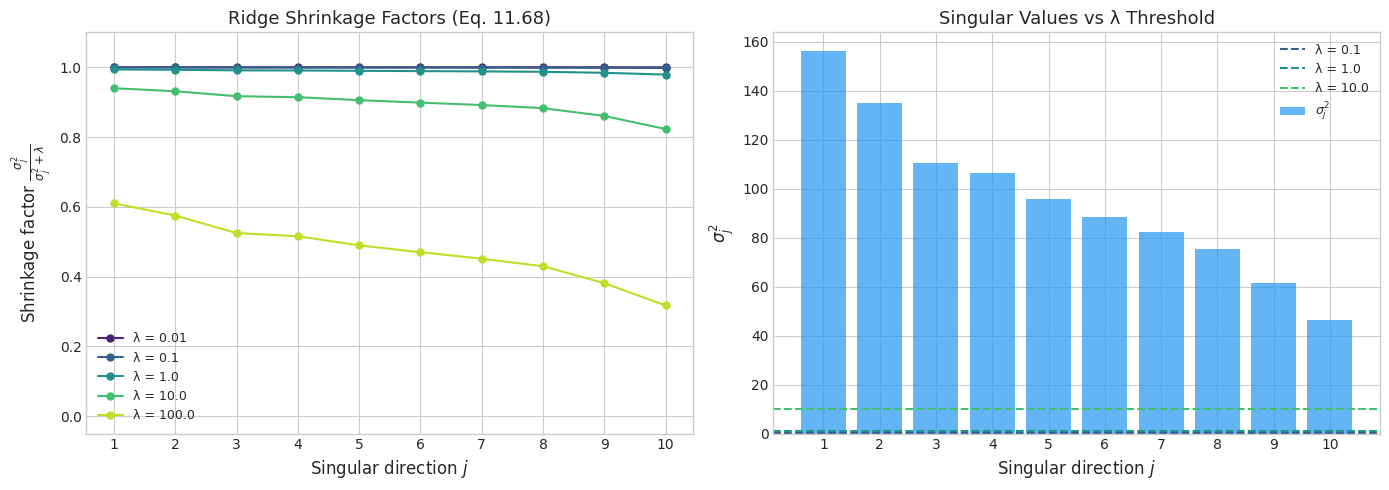

Directions where σⱼ² ≫ λ are preserved (shrinkage ≈ 1).
Directions where σⱼ² ≪ λ are suppressed (shrinkage ≈ 0).
This is 'soft PCA' — unlike hard PCA which keeps K directions and drops the rest.


In [8]:
# Demonstrate shrinkage of singular directions (Eq. 11.68-11.69)
U_low, s_low, Vt_low = svd(X_low, full_matrices=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: shrinkage factors for different λ
lambdas_demo = [0.01, 0.1, 1.0, 10.0, 100.0]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(lambdas_demo)))

for lam_d, col in zip(lambdas_demo, colors):
    shrinkage = s_low**2 / (s_low**2 + lam_d)
    axes[0].plot(range(1, D_low+1), shrinkage, 'o-', color=col, markersize=5,
                 label=f'λ = {lam_d}')

axes[0].set_xlabel('Singular direction $j$', fontsize=12)
axes[0].set_ylabel(r'Shrinkage factor $\frac{\sigma_j^2}{\sigma_j^2 + \lambda}$', fontsize=12)
axes[0].set_title('Ridge Shrinkage Factors (Eq. 11.68)', fontsize=13)
axes[0].legend(fontsize=9)
axes[0].set_ylim(-0.05, 1.1)
axes[0].set_xticks(range(1, D_low+1))

# Right: singular values of X and the shrinkage threshold
axes[1].bar(range(1, D_low+1), s_low**2, color='#2196F3', alpha=0.7, label='$\\sigma_j^2$')
for lam_d, col in zip([0.1, 1.0, 10.0], colors[1:4]):
    axes[1].axhline(lam_d, color=col, linestyle='--', linewidth=1.5,
                    label=f'λ = {lam_d}')
axes[1].set_xlabel('Singular direction $j$', fontsize=12)
axes[1].set_ylabel('$\\sigma_j^2$', fontsize=12)
axes[1].set_title('Singular Values vs λ Threshold', fontsize=13)
axes[1].legend(fontsize=9)
axes[1].set_xticks(range(1, D_low+1))

plt.tight_layout()
plt.show()

print("Directions where σⱼ² ≫ λ are preserved (shrinkage ≈ 1).")
print("Directions where σⱼ² ≪ λ are suppressed (shrinkage ≈ 0).")
print("This is 'soft PCA' — unlike hard PCA which keeps K directions and drops the rest.")

## 7. Effective Degrees of Freedom (Section 11.3.2)

The **effective degrees of freedom** (Eq. 11.71) summarizes how many parameters the model effectively uses:

$$\text{dof}(\lambda) = \sum_{j=1}^{D} \frac{\sigma_j^2}{\sigma_j^2 + \lambda}$$

- When $\lambda = 0$: $\text{dof} = D$ (OLS uses all $D$ parameters)
- When $\lambda \to \infty$: $\text{dof} \to 0$ (all weights shrunk to zero)

This is more informative than simply counting parameters, because ridge uses all $D$ parameters but with varying effective strength.

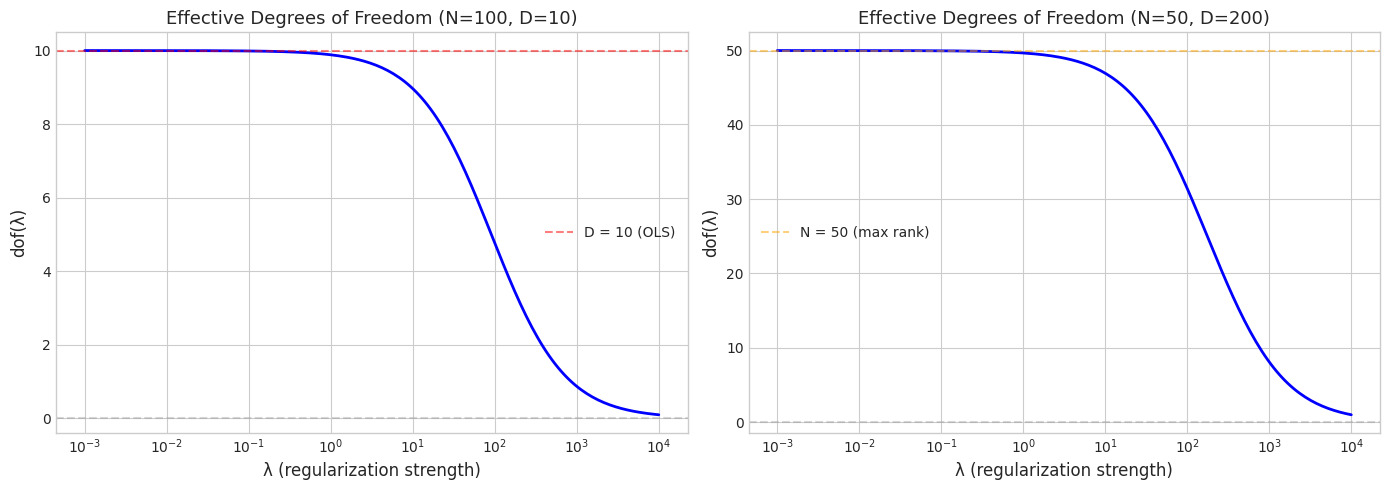

  λ =  0.001  →  dof_low = 10.00,  dof_high = 50.00
  λ =  0.100  →  dof_low = 9.99,  dof_high = 49.97
  λ =  1.000  →  dof_low = 9.88,  dof_high = 49.67
  λ = 10.000  →  dof_low = 8.96,  dof_high = 46.94
  λ = 100.000  →  dof_low = 4.76,  dof_high = 31.42


In [9]:
def effective_dof(singular_values, lam):
    """Effective degrees of freedom (Eq. 11.71)."""
    return np.sum(singular_values**2 / (singular_values**2 + lam))


# Compute dof(λ) for a range of λ values
lambdas = np.logspace(-3, 4, 200)
dof_low = [effective_dof(s_low, l) for l in lambdas]

_, s_high, _ = svd(X_high, full_matrices=False)
dof_high = [effective_dof(s_high, l) for l in lambdas]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogx(lambdas, dof_low, 'b-', linewidth=2)
axes[0].axhline(D_low, color='red', linestyle='--', alpha=0.5, label=f'D = {D_low} (OLS)')
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.3)
axes[0].set_xlabel('λ (regularization strength)', fontsize=12)
axes[0].set_ylabel('dof(λ)', fontsize=12)
axes[0].set_title(f'Effective Degrees of Freedom (N={N_low}, D={D_low})', fontsize=13)
axes[0].legend(fontsize=10)

axes[1].semilogx(lambdas, dof_high, 'b-', linewidth=2)
axes[1].axhline(N_high, color='orange', linestyle='--', alpha=0.5, label=f'N = {N_high} (max rank)')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.3)
axes[1].set_xlabel('λ (regularization strength)', fontsize=12)
axes[1].set_ylabel('dof(λ)', fontsize=12)
axes[1].set_title(f'Effective Degrees of Freedom (N={N_high}, D={D_high})', fontsize=13)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

# Print specific values
for l in [0.001, 0.1, 1.0, 10.0, 100.0]:
    print(f"  λ = {l:>6.3f}  →  dof_low = {effective_dof(s_low, l):.2f},  dof_high = {effective_dof(s_high, l):.2f}")

## 8. Geometry of Ridge Regression (PML Figure 11.7)

The MAP estimate lies at the intersection of the **likelihood ellipse** (contours of RSS) and the **prior circle** (contours of $\|\mathbf{w}\|_2^2$).

The parameter $w_1$ (horizontal) is poorly determined by the data (wide likelihood along that direction), so ridge shrinks it strongly toward zero. The parameter $w_2$ (vertical) is well-determined, so ridge barely moves it. This is the **shrinkage** effect: ill-determined parameters are pulled most toward zero.

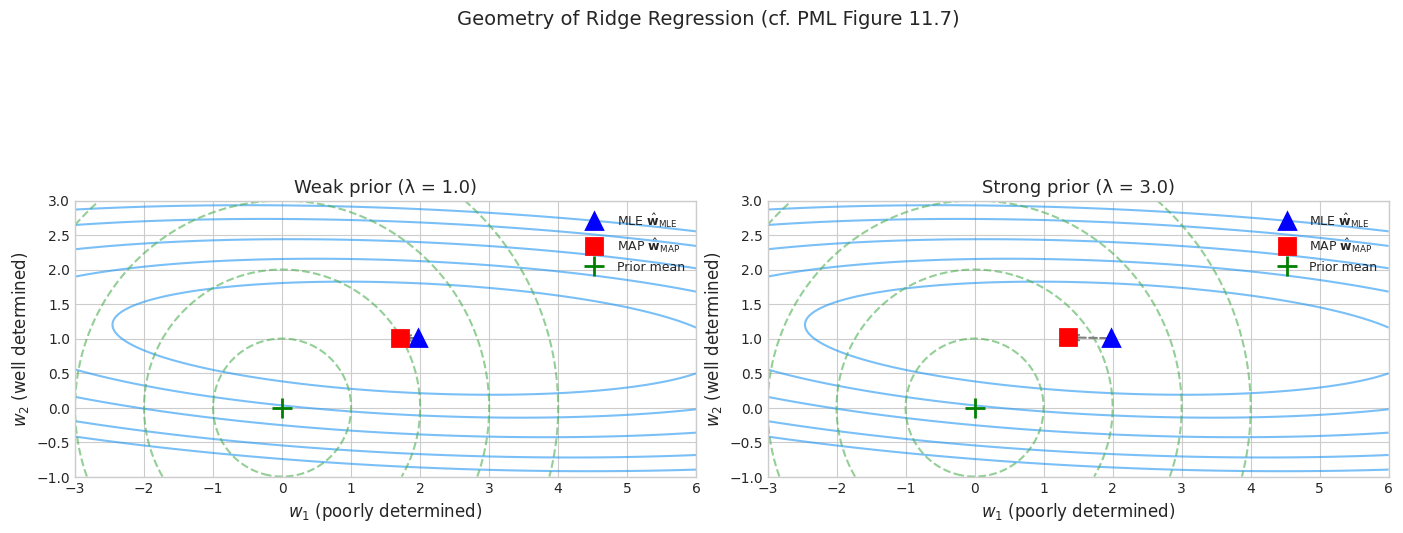

MLE:                w₁ = 1.97,  w₂ = 1.01
MAP (λ=1.0):  w₁ = 1.71,  w₂ = 1.01
MAP (λ=3.0):  w₁ = 1.36,  w₂ = 1.02

w₁ (poorly determined) is shrunk much more than w₂ (well determined).


In [10]:
# Geometry of ridge regression (cf. PML Figure 11.7)
# Create a 2D example with different variances along the two axes
np.random.seed(10)
N_geo = 30
# Data where w1 is poorly determined (small variance in x1) and w2 is well-determined
X_geo = np.random.randn(N_geo, 2)
X_geo[:, 0] *= 0.5   # x1 has low variance → w1 poorly determined
X_geo[:, 1] *= 3.0   # x2 has high variance → w2 well-determined
w_true_geo = np.array([2.0, 1.0])
y_geo = X_geo @ w_true_geo + np.random.randn(N_geo) * 1.5

# MLE and MAP estimates
w_mle_geo = np.linalg.solve(X_geo.T @ X_geo, X_geo.T @ y_geo)
lam_geo = 3.0
w_map_geo = np.linalg.solve(X_geo.T @ X_geo + lam_geo * np.eye(2), X_geo.T @ y_geo)

# Create grid for contour plots
w1_range = np.linspace(-3, 6, 200)
w2_range = np.linspace(-1, 3, 200)
W1, W2 = np.meshgrid(w1_range, w2_range)

# RSS surface
RSS_geo = np.zeros_like(W1)
for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        w_ij = np.array([W1[i, j], W2[i, j]])
        r = y_geo - X_geo @ w_ij
        RSS_geo[i, j] = r @ r

# Prior contours (||w||^2)
Prior_geo = W1**2 + W2**2

# Penalized objective
Penalty_geo = RSS_geo + lam_geo * Prior_geo

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, title, lam_val in zip(axes, [f'Weak prior (λ = {lam_geo/3:.1f})', f'Strong prior (λ = {lam_geo:.1f})'],
                                [lam_geo/3, lam_geo]):
    w_map_i = np.linalg.solve(X_geo.T @ X_geo + lam_val * np.eye(2), X_geo.T @ y_geo)
    
    # RSS contours (likelihood)
    rss_levels = np.percentile(RSS_geo, [30, 50, 65, 80, 90])
    cs_rss = ax.contour(W1, W2, RSS_geo, levels=rss_levels, colors='#2196F3', alpha=0.6)
    
    # Prior contours (ℓ₂ ball)
    prior_levels = [1, 4, 9, 16]
    cs_prior = ax.contour(W1, W2, Prior_geo, levels=prior_levels, colors='#4CAF50',
                          linestyles='--', alpha=0.6)
    
    # Points
    ax.plot(*w_mle_geo, 'b^', markersize=12, markeredgewidth=2, label='MLE $\\hat{\\mathbf{w}}_{\\mathrm{MLE}}$', zorder=5)
    ax.plot(*w_map_i, 'rs', markersize=12, markeredgewidth=2, label='MAP $\\hat{\\mathbf{w}}_{\\mathrm{MAP}}$', zorder=5)
    ax.plot(0, 0, 'g+', markersize=15, markeredgewidth=2, label='Prior mean', zorder=5)
    
    # Arrow from MLE to MAP
    ax.annotate('', xy=w_map_i, xytext=w_mle_geo,
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5, linestyle='--'))
    
    ax.set_xlabel('$w_1$ (poorly determined)', fontsize=12)
    ax.set_ylabel('$w_2$ (well determined)', fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=9, loc='upper right')
    ax.set_aspect('equal')

plt.suptitle('Geometry of Ridge Regression (cf. PML Figure 11.7)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"MLE:                w₁ = {w_mle_geo[0]:.2f},  w₂ = {w_mle_geo[1]:.2f}")
print(f"MAP (λ={lam_geo/3:.1f}):  w₁ = {np.linalg.solve(X_geo.T @ X_geo + (lam_geo/3) * np.eye(2), X_geo.T @ y_geo)[0]:.2f},  w₂ = {np.linalg.solve(X_geo.T @ X_geo + (lam_geo/3) * np.eye(2), X_geo.T @ y_geo)[1]:.2f}")
print(f"MAP (λ={lam_geo:.1f}):  w₁ = {w_map_geo[0]:.2f},  w₂ = {w_map_geo[1]:.2f}")
print(f"\nw₁ (poorly determined) is shrunk much more than w₂ (well determined).")

## 9. Choosing λ — Cross-Validation and the Regularization Path (Section 11.3.3)

We choose the optimal $\lambda$ by trying multiple values and estimating their test error via **K-fold cross-validation**.

The **regularization path** traces how each weight $\hat{w}_d(\lambda)$ changes as we vary $\lambda$ from large (strong regularization, all weights near zero) to small (no regularization, OLS). We can warm-start: use $\hat{\mathbf{w}}(\lambda_k)$ as the initializer for $\hat{\mathbf{w}}(\lambda_{k+1})$.

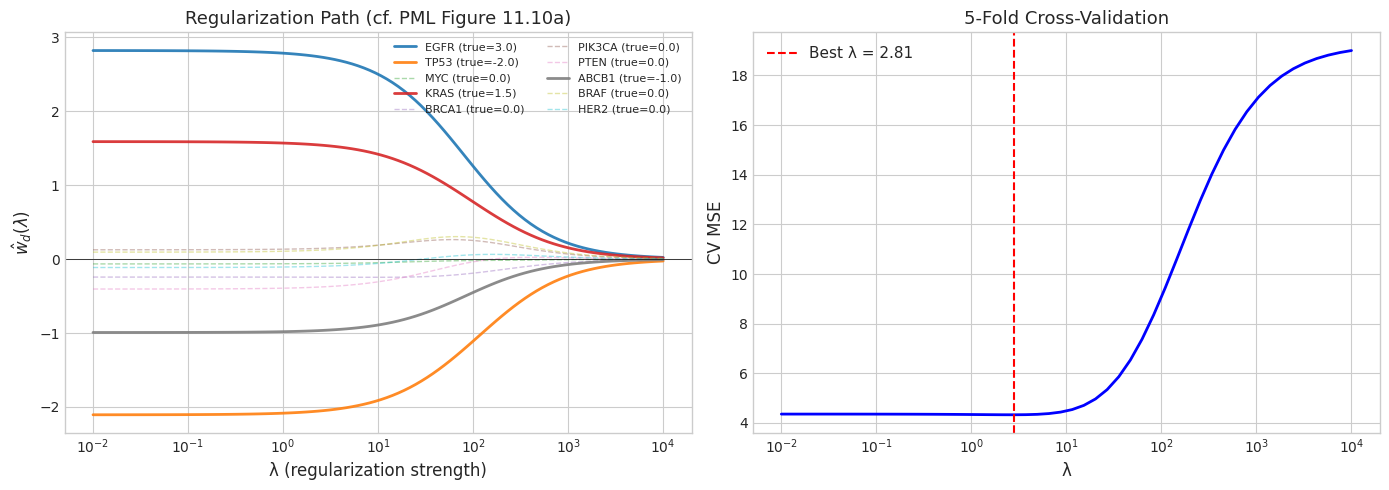

Best λ by 5-fold CV: 2.81
  dof(λ*) = 9.68
  Test MSE = 4.996  (OLS: 4.964)


In [11]:
# Regularization path: weights as a function of λ
lambdas_path = np.logspace(-2, 4, 100)
weights_path = np.array([ridge_direct(X_low, y_low, l) for l in lambdas_path])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: regularization path
for d in range(D_low):
    style = '-' if w_true_low[d] != 0 else '--'
    alpha = 0.9 if w_true_low[d] != 0 else 0.4
    axes[0].semilogx(lambdas_path, weights_path[:, d], style, alpha=alpha,
                     linewidth=2 if w_true_low[d] != 0 else 1,
                     label=f'{gene_names[d]} (true={w_true_low[d]:.1f})')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_xlabel('λ (regularization strength)', fontsize=12)
axes[0].set_ylabel('$\\hat{w}_d(\\lambda)$', fontsize=12)
axes[0].set_title('Regularization Path (cf. PML Figure 11.10a)', fontsize=13)
axes[0].legend(fontsize=8, ncol=2, loc='upper right')

# Right: cross-validation to select λ
K = 5  # K-fold CV
n_lambdas = 50
lambdas_cv = np.logspace(-2, 4, n_lambdas)
cv_errors = np.zeros(n_lambdas)

indices = np.arange(N_low)
np.random.shuffle(indices)
folds = np.array_split(indices, K)

for i, lam_cv in enumerate(lambdas_cv):
    fold_errors = []
    for k in range(K):
        val_idx = folds[k]
        train_idx = np.concatenate([folds[j] for j in range(K) if j != k])
        
        X_tr, y_tr = X_low[train_idx], y_low[train_idx]
        X_val, y_val = X_low[val_idx], y_low[val_idx]
        
        w_cv = ridge_direct(X_tr, y_tr, lam_cv)
        fold_errors.append(np.mean((X_val @ w_cv - y_val)**2))
    cv_errors[i] = np.mean(fold_errors)

best_idx = np.argmin(cv_errors)
best_lambda = lambdas_cv[best_idx]

axes[1].semilogx(lambdas_cv, cv_errors, 'b-', linewidth=2)
axes[1].axvline(best_lambda, color='red', linestyle='--', linewidth=1.5,
                label=f'Best λ = {best_lambda:.2f}')
axes[1].set_xlabel('λ', fontsize=12)
axes[1].set_ylabel('CV MSE', fontsize=12)
axes[1].set_title(f'{K}-Fold Cross-Validation', fontsize=13)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

# Evaluate best ridge model
w_best = ridge_direct(X_low, y_low, best_lambda)
mse_best = np.mean((X_low_test @ w_best - y_low_test)**2)
print(f"Best λ by {K}-fold CV: {best_lambda:.2f}")
print(f"  dof(λ*) = {effective_dof(s_low, best_lambda):.2f}")
print(f"  Test MSE = {mse_best:.3f}  (OLS: {mse_ols_low:.3f})")

## 10. Ridge vs OLS — Bias-Variance Tradeoff

Ridge introduces **bias** (weights shrunk toward zero) but reduces **variance** (less sensitivity to training noise). The optimal λ balances this tradeoff, especially critical when $D \gg N$.

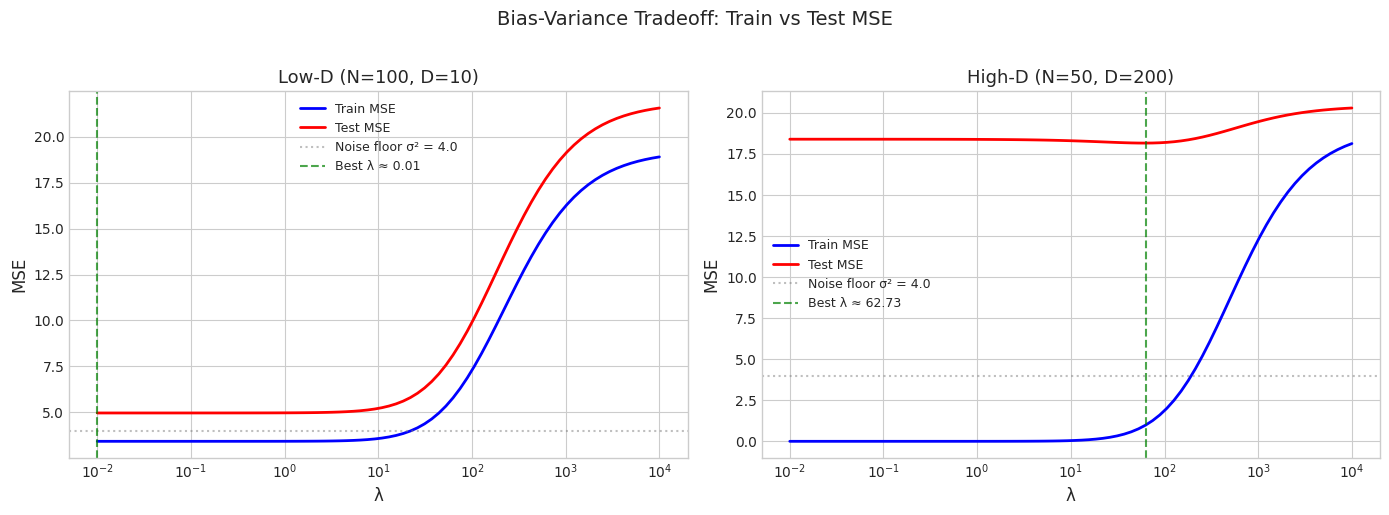

Small λ → low bias, high variance (overfitting).
Large λ → high bias, low variance (underfitting).
The optimal λ minimizes test error — the sweet spot of the bias-variance tradeoff.


In [12]:
# Bias-variance tradeoff: train and test MSE as a function of λ
lambdas_bv = np.logspace(-2, 4, 80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, X_tr, y_tr, X_te, y_te, N_tr, D_tr, title in [
    (axes[0], X_low, y_low, X_low_test, y_low_test, N_low, D_low, f'Low-D (N={N_low}, D={D_low})'),
    (axes[1], X_high, y_high, X_high_test, y_high_test, N_high, D_high, f'High-D (N={N_high}, D={D_high})')
]:
    train_mse = []
    test_mse = []
    for l in lambdas_bv:
        w_l = ridge_direct(X_tr, y_tr, l)
        train_mse.append(np.mean((X_tr @ w_l - y_tr)**2))
        test_mse.append(np.mean((X_te @ w_l - y_te)**2))
    
    ax.semilogx(lambdas_bv, train_mse, 'b-', linewidth=2, label='Train MSE')
    ax.semilogx(lambdas_bv, test_mse, 'r-', linewidth=2, label='Test MSE')
    ax.axhline(sigma_noise**2, color='gray', linestyle=':', alpha=0.5,
               label=f'Noise floor σ² = {sigma_noise**2}')
    
    best_idx = np.argmin(test_mse)
    ax.axvline(lambdas_bv[best_idx], color='green', linestyle='--', alpha=0.7,
               label=f'Best λ ≈ {lambdas_bv[best_idx]:.2f}')
    
    ax.set_xlabel('λ', fontsize=12)
    ax.set_ylabel('MSE', fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=9)

plt.suptitle('Bias-Variance Tradeoff: Train vs Test MSE', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Small λ → low bias, high variance (overfitting).")
print("Large λ → high bias, low variance (underfitting).")
print("The optimal λ minimizes test error — the sweet spot of the bias-variance tradeoff.")

## 11. Ridge vs Principal Components Regression

**PC regression** first reduces dimensionality to $K$ components via PCA, then regresses on those. This is a **hard** cutoff: the first $K$ directions are fully retained, the rest are fully discarded.

Ridge instead applies **soft** weighting via $\sigma_j^2 / (\sigma_j^2 + \lambda)$ — all directions contribute, but weak ones are suppressed. This generally outperforms PC regression because it doesn't arbitrarily discard potentially useful information.

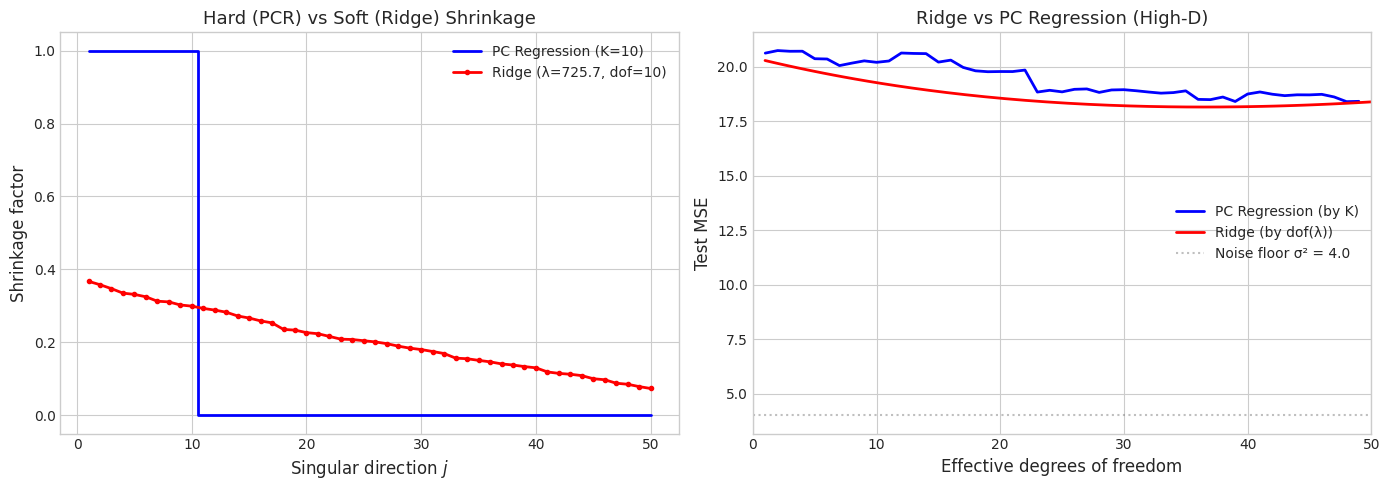

Best PC Regression MSE:  18.408  (K=48)
Best Ridge MSE:          18.161

Ridge's soft shrinkage generally outperforms PCR's hard cutoff.


In [13]:
# Compare Ridge vs PC Regression on the high-D data
U_h, s_h, Vt_h = svd(X_high, full_matrices=False)

def pc_regression(X, y, X_test, K):
    """Principal Components Regression: project onto top-K PCs, then OLS."""
    U, s, Vt = svd(X, full_matrices=False)
    # Project to K-dimensional PC space
    Z_train = U[:, :K] * s[:K]  # N × K
    Z_test = X_test @ Vt[:K].T  # project test data
    # OLS in PC space
    w_pc = np.linalg.lstsq(Z_train, y, rcond=None)[0]
    return Z_test @ w_pc

# Sweep K for PC regression and λ for ridge
Ks = range(1, N_high)
pcr_test_mse = []
for K in Ks:
    y_pred = pc_regression(X_high, y_high, X_high_test, K)
    pcr_test_mse.append(np.mean((y_pred - y_high_test)**2))

lambdas_comp = np.logspace(-1, 4, 80)
ridge_test_mse = []
ridge_dofs = []
for l in lambdas_comp:
    w_r = ridge_direct(X_high, y_high, l)
    ridge_test_mse.append(np.mean((X_high_test @ w_r - y_high_test)**2))
    ridge_dofs.append(effective_dof(s_h, l))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: shrinkage comparison (hard vs soft)
K_example = 10
ax = axes[0]
hard_shrinkage = np.zeros(len(s_h))
hard_shrinkage[:K_example] = 1.0

# Find λ that gives similar dof
target_dof = K_example
lam_match = lambdas_comp[np.argmin(np.abs(np.array(ridge_dofs) - target_dof))]
soft_shrinkage = s_h**2 / (s_h**2 + lam_match)

ax.step(range(1, len(s_h)+1), hard_shrinkage, 'b-', linewidth=2, where='mid',
        label=f'PC Regression (K={K_example})')
ax.plot(range(1, len(s_h)+1), soft_shrinkage, 'r-o', linewidth=2, markersize=3,
        label=f'Ridge (λ={lam_match:.1f}, dof={target_dof:.0f})')
ax.set_xlabel('Singular direction $j$', fontsize=12)
ax.set_ylabel('Shrinkage factor', fontsize=12)
ax.set_title('Hard (PCR) vs Soft (Ridge) Shrinkage', fontsize=13)
ax.legend(fontsize=10)

# Right: test MSE comparison
axes[1].plot(list(Ks), pcr_test_mse, 'b-', linewidth=2, label='PC Regression (by K)')
axes[1].plot(ridge_dofs, ridge_test_mse, 'r-', linewidth=2, label='Ridge (by dof(λ))')
axes[1].axhline(sigma_noise**2, color='gray', linestyle=':', alpha=0.5,
                label=f'Noise floor σ² = {sigma_noise**2}')
axes[1].set_xlabel('Effective degrees of freedom', fontsize=12)
axes[1].set_ylabel('Test MSE', fontsize=12)
axes[1].set_title('Ridge vs PC Regression (High-D)', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].set_xlim(0, N_high)

plt.tight_layout()
plt.show()

best_pcr = min(pcr_test_mse)
best_ridge = min(ridge_test_mse)
print(f"Best PC Regression MSE:  {best_pcr:.3f}  (K={np.argmin(pcr_test_mse)+1})")
print(f"Best Ridge MSE:          {best_ridge:.3f}")
print(f"\nRidge's soft shrinkage generally outperforms PCR's hard cutoff.")

## Summary

### Key Takeaways

- **Ridge regression** is MAP estimation with a Gaussian prior $p(\mathbf{w}) = \mathcal{N}(\mathbf{0}, \tau^2\mathbf{I})$, equivalent to ℓ₂ regularization
- The penalty $\lambda\|\mathbf{w}\|_2^2$ ensures $\mathbf{X}^\top\mathbf{X} + \lambda\mathbf{I}$ is always invertible, even when $D > N$
- **Augmented data + QR** converts ridge to standard OLS: append virtual observations from the prior
- **SVD approach** is efficient when $D > N$: solve in the $N$-dimensional reduced space instead of $D$
- Ridge applies **soft shrinkage** $\sigma_j^2/(\sigma_j^2 + \lambda)$ to each singular direction — poorly determined directions (small $\sigma_j$) are suppressed most
- **Effective degrees of freedom** $\text{dof}(\lambda) = \sum \sigma_j^2/(\sigma_j^2 + \lambda)$ smoothly interpolates between $D$ (OLS) and $0$ (null model)
- **Geometry**: the MAP estimate sits where the likelihood ellipse meets the prior circle — ill-determined parameters are shrunk most toward zero
- Choose $\lambda$ via **cross-validation** or the regularization path; soft shrinkage generally outperforms hard PCA truncation

### Key Formulas from Chapter 11.3

| Concept | Formula |
|---------|--------|
| Penalized objective (Eq. 11.55) | $J(\mathbf{w}) = \text{RSS}(\mathbf{w}) + \lambda\|\mathbf{w}\|_2^2$ |
| MAP estimate (Eq. 11.57) | $\hat{\mathbf{w}} = (\mathbf{X}^\top\mathbf{X} + \lambda\mathbf{I})^{-1}\mathbf{X}^\top\mathbf{y}$ |
| Augmented data (Eq. 11.58) | $\tilde{\mathbf{X}} = [\mathbf{X}/\sigma;\; \sqrt{\Lambda}]$ |
| SVD solution (Eq. 11.65) | $\hat{\mathbf{w}} = \mathbf{V}(\mathbf{R}^\top\mathbf{R} + \lambda\mathbf{I}_N)^{-1}\mathbf{R}^\top\mathbf{y}$ |
| Shrinkage factor (Eq. 11.68) | $\sigma_j^2 / (\sigma_j^2 + \lambda)$ |
| Effective dof (Eq. 11.71) | $\text{dof}(\lambda) = \sum_j \sigma_j^2 / (\sigma_j^2 + \lambda)$ |